# NVDA — Stateless Methods: Systematic Backtest

> **Part 4 of 6.** Builds on [`03_one_agent_two_tasks.ipynb`](03_one_agent_two_tasks.ipynb).
> Next: [`05_discovery_loop.ipynb`](05_discovery_loop.ipynb) (Phase 2), then `06` (the protected 2026 evaluation).

Every method so far is **stateless**: configured once and run the same way at every
origin. This notebook scores all of them on the full 2025 backtest (51 weekly origins,
5/10/21-day horizons, plus the ±5% shock task) and asks three questions:

1. **Is it accurate?** The CRPS leaderboard.
2. **Is it honest?** Interval coverage against width.
3. **Where does the error come from?** Shock windows and volatility regimes.

Everything reads the committed prediction YAMLs by globbing the registry, so a new
predictor appears the moment its results land in `data/predictions/<spec_id>/`.

> Run from `implementations/` after `uv run python scripts/fetch_nvda.py`. No LLM calls.

In [1]:
import warnings
from datetime import datetime


warnings.filterwarnings("ignore")

import pandas as pd
from ai_stocks_forecasting.analysis import leaderboard_with_uncertainty, per_horizon_crps
from ai_stocks_forecasting.charts import (
    coverage_sharpness,
    coverage_sharpness_table,
    load_scored_frame,
    load_shock_frame,
    predicted_vs_actual,
    shock_leaderboard,
    shock_separation,
)
from ai_stocks_forecasting.data import NVDA_SERIES_ID, build_nvda_service
from ai_stocks_forecasting.story import regime_crps_chart, regime_crps_table, shock_window_crps


SPEC_ID = "nvda_backtest"  # swap to "nvda_eval" for the protected 2026 window

pd.set_option("display.width", 160)
data_service = build_nvda_service()
prices = data_service.get_series(NVDA_SERIES_ID, as_of=datetime.now())
frame = load_scored_frame(SPEC_ID, data_service)

print(f"{SPEC_ID}: {len(frame)} scored predictions across {frame['predictor'].nunique()} predictors")
print(f"predictors: {', '.join(sorted(frame['predictor'].unique()))}")

nvda_backtest: 435 scored predictions across 3 predictors
predictors: AutoARIMA (log returns), Naive (last value), News agent


## 1. Leaderboard

CRPS in USD per share, lower is better. `se` is the standard error: when the gap between
two predictors is small next to it, the ranking is not meaningful.

The naive row repeats the last close with no interval, so its CRPS is just its absolute
error. Any predictor that emits an interval is held to a stricter standard.

In [2]:
leaderboard_with_uncertainty(frame).round(3)

,mean_crps,se,n,family
predictor,,,,
News agent,8.010,0.522,145,LLM / Agent
AutoARIMA (log returns),8.174,0.321,145,Numerical ML
Naive (last value),10.665,0.625,145,Baseline


In [3]:
per_horizon_crps(frame).round(2)

,h=5d,h=10d,h=21d,All
predictor,,,,
News agent,6.29,7.39,10.17,8.01
AutoARIMA (log returns),6.25,7.60,10.48,8.17
Naive (last value),8.23,10.09,13.44,10.67


A paired view of the close race: at each origin and horizon, the agent's CRPS minus
AutoARIMA's. Negative means the agent was better there.

In [4]:
wide = frame.pivot_table(index=["as_of", "horizon"], columns="predictor", values="crps")
diff = wide["News agent"] - wide["AutoARIMA (log returns)"]
paired = diff.groupby(level="horizon").agg(mean_diff="mean", se=lambda s: s.std() / len(s) ** 0.5)
paired["agent_better_share"] = (diff < 0).groupby(level="horizon").mean()
paired.round(2)

,mean_diff,se,agent_better_share
horizon,,,
5,0.04,0.32,0.64
10,-0.21,0.49,0.66
21,-0.31,0.62,0.63


## 2. Coverage vs sharpness

An 80% interval promises to contain the outcome 80% of the time. The chart plots what
each predictor delivered against how wide an interval it needed.

- **On the dashed line**: honest. Further *left* on the line is more useful.
- **Below the line**: overconfident; the interval is too narrow.
- **Above the line**: under-confident; correct but vague.

Horizons are faceted because width is in dollars and not comparable across them.

In [5]:
coverage_sharpness_table(frame)

coverage_80  mean_width  mean_crps   n  miscalibration
family       predictor               horizon                                                        
Baseline     Naive (last value)      5               0.00        0.00       8.23  47           -80.0
                                     10              0.00        0.00      10.09  47           -80.0
                                     21              0.00        0.00      13.44  51           -80.0
LLM / Agent  News agent              5              59.57       14.76       6.29  47           -20.4
                                     10             70.21       24.59       7.39  47            -9.8
                                     21             68.63       42.08      10.17  51           -11.4
Numerical ML AutoARIMA (log returns) 5              82.98       32.83       6.25  47             3.0
                                     10             89.36       46.53       7.60  47             9.4
                                     21             98.04       68.51      10.48  51            18.0

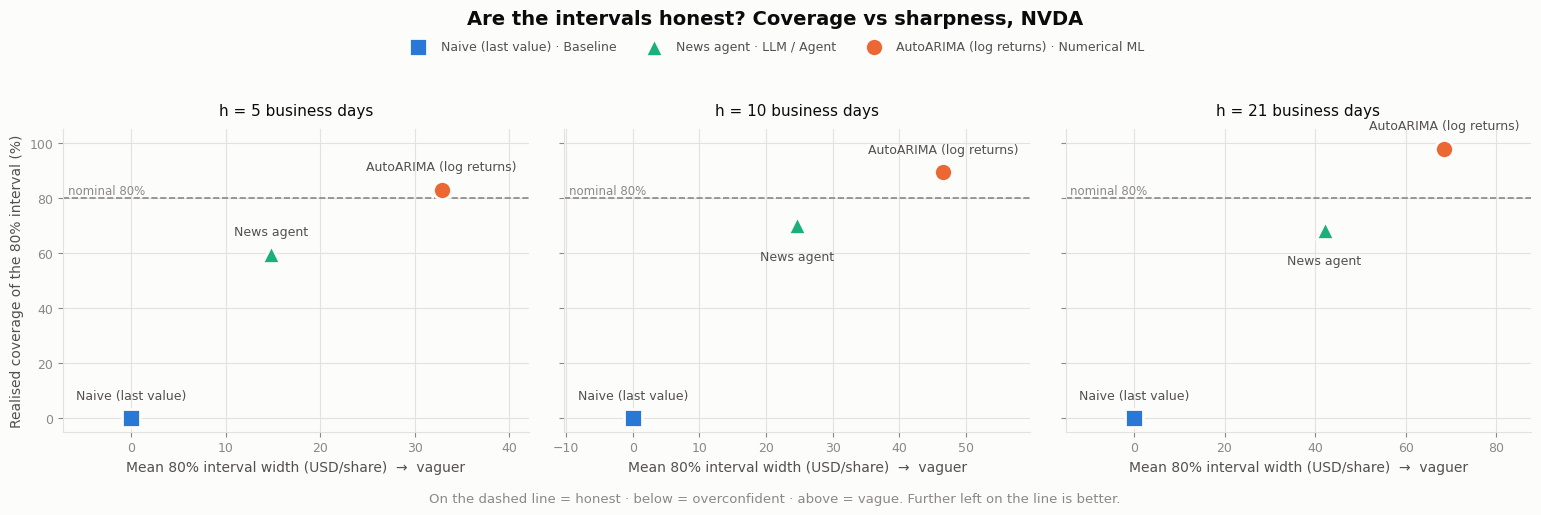

In [6]:
fig, axes = coverage_sharpness(frame)

## 3. Where the error comes from

**Shock windows.** Each forecast is tagged by whether a ±5% session fell between its
origin and its target date.

In [7]:
shock_window_crps(frame, prices)

window                           no shock  shock in window  windows with a shock (%)
predictor               horizon                                                     
AutoARIMA (log returns) 5            4.70             9.53                        32
                        10           6.63             9.31                        36
                        21           9.58            11.50                        47
Naive (last value)      5            5.87            13.25                        32
                        10           8.48            12.94                        36
                        21          11.97            15.09                        47
News agent              5            3.91            11.36                        32
                        10           4.83            11.89                        36
                        21           7.23            13.48                        47

**Volatility regimes.** Each origin is labelled low / normal / high by its trailing
21-session volatility, measured against all earlier history so the label never uses
the future (`signals.label_regimes`).

In [8]:
regimes = regime_crps_table(frame, prices)
regimes

,low (22 origins),normal (16 origins),high (13 origins)
predictor,,,
AutoARIMA (log returns),7.29,8.62,9.17
Naive (last value),9.11,10.65,13.37
News agent,5.56,9.08,10.97


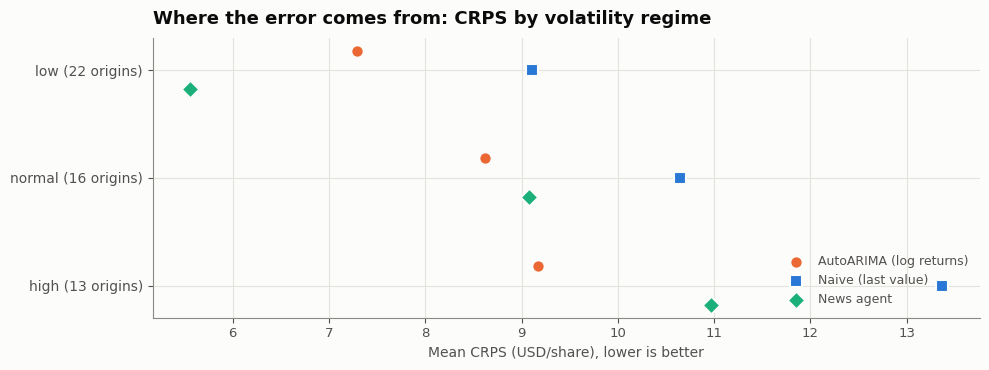

In [9]:
fig, ax = regime_crps_chart(regimes)

## 4. Predicted vs actual

The black line is the actual close. Each predictor's median is plotted at the date it
was *forecasting*, with its 80% band, one panel per horizon. A perfect forecaster would
sit on the black line. The naive forecast is the black line shifted right by the horizon.

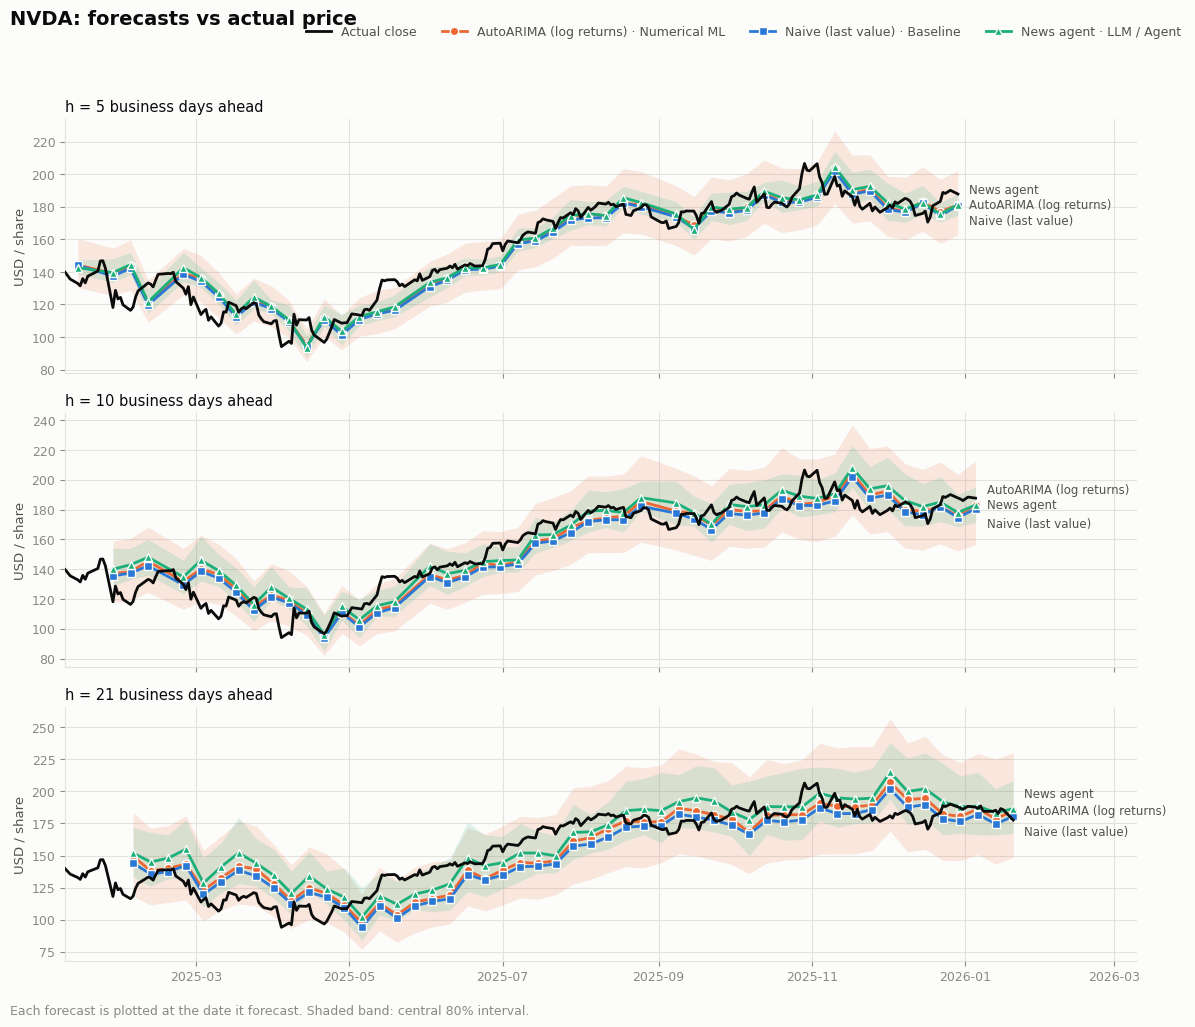

In [10]:
fig, axes = predicted_vs_actual(frame, data_service)

## 5. Every prediction, in full

One row per predictor, origin and horizon. Uncomment a line to print every row or save a
CSV to the gitignored `data/` folder.

In [11]:
columns = [
    "predictor",
    "as_of",
    "forecast_date",
    "horizon",
    "q10",
    "q50",
    "q90",
    "actual",
    "abs_error",
    "crps",
    "inside80",
]
predictions = frame[columns].sort_values(["predictor", "as_of", "horizon"]).reset_index(drop=True)
two_dp = dict.fromkeys(predictions.select_dtypes("number").columns, 2)

# pd.set_option("display.max_rows", None)
# from ai_stocks_forecasting.paths import DATA_DIR; predictions.to_csv(DATA_DIR / "nvda_backtest_predictions.csv", index=False)

predictions[predictions["as_of"] == "2025-04-07"].round(two_dp)

,predictor,as_of,forecast_date,horizon,q10,q50,q90,actual,abs_error,crps,inside80
35,AutoARIMA (log returns),2025-04-07,2025-04-14,5,84.88,94.96,105.09,110.43,15.47,10.84,0.0
36,AutoARIMA (log returns),2025-04-07,2025-04-21,10,82.06,95.56,110.44,96.67,1.10,3.08,1.0
37,AutoARIMA (log returns),2025-04-07,2025-05-06,21,76.82,97.59,120.18,113.25,15.66,9.23,1.0
180,Naive (last value),2025-04-07,2025-04-14,5,94.07,94.07,94.07,110.43,16.36,16.36,0.0
181,Naive (last value),2025-04-07,2025-04-21,10,94.07,94.07,94.07,96.67,2.59,2.59,0.0
182,Naive (last value),2025-04-07,2025-05-06,21,94.07,94.07,94.07,113.25,19.18,19.18,0.0
325,News agent,2025-04-07,2025-04-14,5,87.50,93.50,101.00,110.43,16.93,13.26,0.0
326,News agent,2025-04-07,2025-04-21,10,85.00,96.00,109.00,96.67,0.67,2.30,1.0
327,News agent,2025-04-07,2025-05-06,21,84.00,102.00,125.00,113.25,11.25,6.86,1.0


## 6. The shock task

One probability per origin: will the next session close at least 5% away from the
previous close? Scored with the **Brier score** (lower is better) against
**climatology**, which always forecasts the historical shock rate (about 13%).

- **`brier_skill`** = 1 − Brier ÷ climatology's Brier; above 0 beats climatology.
- **`separation`** = mean P before shocks minus mean P before calm sessions.
- **`diff_lo` / `diff_hi`** = 90% paired-bootstrap interval on Brier minus climatology's;
  containing 0 means noise.
- **`leaked_origins`** = midnight forecasts quoting the `as_of` close they cannot know.

`nvda_shock_smoke` is half shocks by construction, so its Brier rewards any higher
average P; read its separation, not its skill.

In [12]:
shocks = load_shock_frame(data_service)
shock_leaderboard(shocks)

n  shocks  leaked_origins  brier  mean_p_shock  mean_p_calm  separation  brier_skill  diff_lo  diff_hi
spec                   arm                                                                                                                          
nvda_shock_smoke       Agent, no topics      10       5               0  0.358         0.166        0.142       0.024        0.078   -0.053   -0.010
                       Climatology           10       5               0  0.388         0.128        0.128      -0.000          NaN      NaN      NaN
nvda_shock_fresh       Agent, search topics  16       3               0  0.165         0.163        0.190      -0.027       -0.057   -0.018    0.030
                       Agent, no topics      16       3               0  0.159         0.153        0.171      -0.017       -0.018   -0.009    0.012
                       Climatology           16       3               0  0.156         0.129        0.128       0.000          NaN      NaN      NaN
nvda_shock_fresh_close Agent, after close    16       3               0  0.154         0.227        0.212       0.015        0.014   -0.043    0.035
                       Climatology           16       3               0  0.156         0.129        0.129       0.000          NaN      NaN      NaN

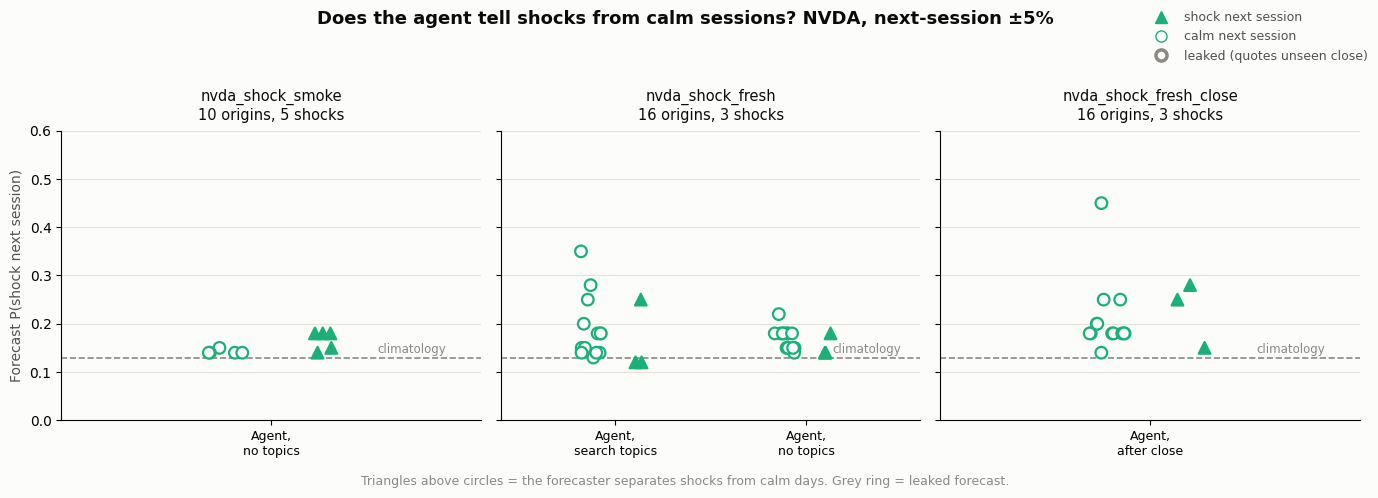

In [13]:
fig, axes = shock_separation(shocks)

## 7. Takeaways — computed from this run

**Trajectory (CRPS).**
- **The agent ties AutoARIMA** (8.01 against 8.17, inside one standard error) and both
  beat naive (10.67). The paired differences per horizon are within their standard errors.
- **It is sharper but overconfident.** Its 80% intervals are about half AutoARIMA's
  width, and contain the outcome only 60%, 70% and 69% of the time at 5, 10 and 21 days.
  AutoARIMA's contain it 83%, 89% and 98%.
- **It wins quiet weeks and loses shock weeks.** With no shock in the window its 5-day
  CRPS is 3.9 against AutoARIMA's 4.7; with a shock, 11.4 against 9.5. The same split
  shows by regime: best in low volatility (5.6 against 7.3), worst in high (11.0 against
  9.2). It beats AutoARIMA at about two origins in three, and gives it back on the shocks.

**Shock (Brier).** No variant beats climatology on the fresh post-cutoff set (0.159 and
0.165 at midnight, 0.154 after close, against 0.156), and none separates shocks from calm
sessions. The fence leak found during review is fixed and the leak column reads 0.

## 8. What stateless methods can't do

A stateless agent reasons from scratch at every origin, anchored on the reference rates
in its prompt. It cannot learn that, say, an export-control headline in a high-volatility
week has historically preceded a shock, because nothing it learns survives to the next
origin.

That is the Phase 2 discovery loop: a study agent proposes news patterns, `signals.py`
tests each against matched controls and a post-cutoff holdout, and only patterns that
clear the graduation gate are written to the strategy file the forecaster reads. The
earnings calendar is the obvious first candidate: an earnings reaction session is a
shock about half the time, against 12% overall.

**Next:** [`05_discovery_loop.ipynb`](05_discovery_loop.ipynb) runs that loop on fifteen candidate patterns; `06` will be the protected 2026 evaluation.